# Project 02 — A Single Proportion (naive pooled admission rate)

**Tier 1 · Foundations** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P02_proportion-admit/P02_proportion-admit_12-06-2026_Opus48.ipynb)

Estimate **one** number — the overall probability of admission at UC Berkeley (1973) — by pooling
all departments. New skill: **grid approximation vs MCMC** give the same posterior for a
one-parameter model, and the *pooled* rate deliberately hides the structure that Project 07 will
reveal as **Simpson's paradox**.

## Learning objectives
1. Build a **Beta-Binomial** model for a single proportion and read its conjugate posterior.
2. Compute the posterior **two ways — grid and MCMC** — and confirm they agree.
3. Run prior predictive on the **outcome scale** (admitted counts / proportion).
4. See *why* a pooled proportion is a trap: the per-gender pooled rates set up the P07 paradox.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
RANDOM_SEED = 2
rng = np.random.default_rng(RANDOM_SEED)
trapz = getattr(np, "trapezoid", None) or np.trapz   # NumPy 2.x renamed trapz->trapezoid
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate `y ~ Binomial(n=1000, p=0.38)`, fit the Beta-Binomial, confirm the known p is recovered.

In [2]:
p_true, n_trials = 0.38, 1000
y_sim = rng.binomial(n_trials, p_true)
with pm.Model() as m0:
    p = pm.Beta("p", 2, 2)
    pm.Binomial("y", n=n_trials, p=p, observed=y_sim)
    idata0 = pm.sample(2000, tune=1000, chains=4, target_accept=0.9,
                       random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk","ess_tail"]])
print("p_true in 90% HDI:", s0.loc["p","hdi_5%"] <= p_true <= s0.loc["p","hdi_95%"])

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [p]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


    mean  hdi_5%  hdi_95%  r_hat  ess_bulk  ess_tail
p  0.384   0.357    0.408    1.0    2890.0    4279.0
p_true in 90% HDI: True


## Data load — UCBadmit (`;`-delimited)

In [3]:
URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/UCBadmit.csv"
CACHE = "data/UCBadmit.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw), sep=";"); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE, sep=";")
df

loaded from raw URL


,dept,applicant.gender,admit,reject,applications
1,A,male,512,313,825
2,A,female,89,19,108
3,B,male,353,207,560
4,B,female,17,8,25
5,C,male,120,205,325
6,C,female,202,391,593
7,D,male,138,279,417
8,D,female,131,244,375
9,E,male,53,138,191
10,E,female,94,299,393


## Stage 1–2 — Question & EDA
**Question:** what is the overall admission probability, pooling all six departments?
**Target:** a single p. **Unit:** one application. We also peek at the *pooled-by-gender* rates —
the seed of the paradox.

In [4]:
tot_admit = int(df.admit.sum()); tot_apps = int(df.applications.sum())
print(f"pooled: {tot_admit}/{tot_apps} = {tot_admit/tot_apps:.3f} admitted overall")
g = df.groupby("applicant.gender").apply(lambda d: d.admit.sum()/d.applications.sum())
print("\npooled admission rate by gender:\n", g.round(3))

pooled: 1755/4526 = 0.388 admitted overall

pooled admission rate by gender:
 applicant.gender
female    0.304
male      0.445
dtype: float64


## Stage 3 — Model specification
$$y \sim \mathrm{Binomial}(N,\,p), \qquad p \sim \mathrm{Beta}(2,2)$$
`y` = total admitted, `N` = total applications. `Beta(2,2)` is a mild prior favouring
mid-range probabilities over the 0/1 extremes (weakly-informative).

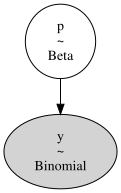

In [5]:
with pm.Model() as model:
    p = pm.Beta("p", 2, 2)
    y = pm.Binomial("y", n=tot_apps, p=p, observed=tot_admit)
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| DAG: p -> y")

## Stage 4 — Prior predictive (outcome scale = admitted proportion)

Sampling: [p, y]


prior-predictive admitted proportion: 5-95% = [0.12, 0.86]


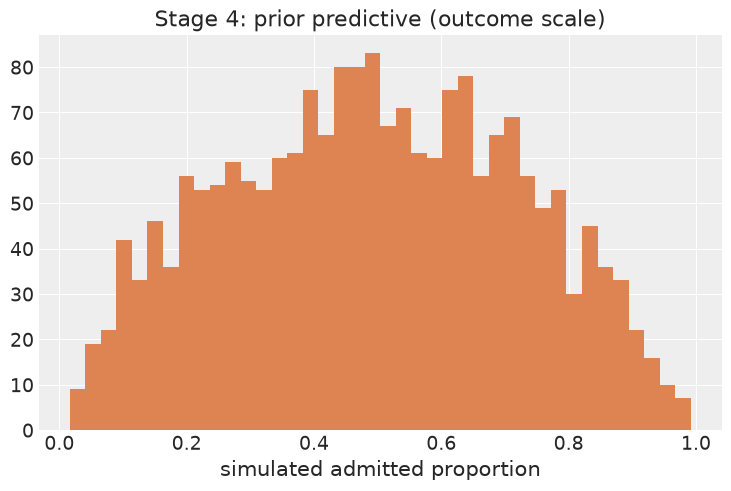

In [6]:
with model:
    prior = pm.sample_prior_predictive(samples=2000, random_seed=RANDOM_SEED)
pp = prior.prior_predictive["y"].values.ravel() / tot_apps
print(f"prior-predictive admitted proportion: 5-95% = [{np.quantile(pp,.05):.2f}, {np.quantile(pp,.95):.2f}]")
plt.hist(pp, bins=40, color="#dd8452"); plt.xlabel("simulated admitted proportion")
plt.title("Stage 4: prior predictive (outcome scale)"); plt.show()

## Stage 5 — Fit (MCMC)

In [7]:
with model:
    idata = pm.sample(2000, tune=1000, chains=4, target_accept=0.9,
                      random_seed=RANDOM_SEED, progressbar=False)
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [p]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


Sampling: [y]


## Stage 6 — Diagnostics

    mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
p  0.388  0.007   0.375    0.403    1.0    3115.0    4618.0

divergences: 0 | BFMI: [1.172 1.297 1.094 1.184]


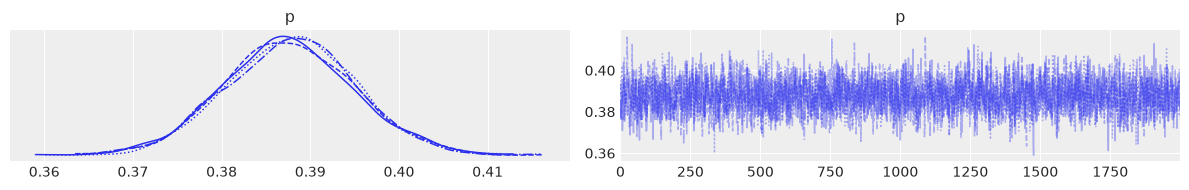

In [8]:
summ = az.summary(idata, hdi_prob=0.94)
print(summ[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
print("\ndivergences:", int(idata.sample_stats.diverging.values.sum()),
      "| BFMI:", np.round(az.bfmi(idata),3))
az.plot_trace(idata); plt.tight_layout(); plt.show()

## Grid approximation vs MCMC (the new skill)
For one parameter we can evaluate the posterior on a grid exactly and overlay the MCMC draws.
The conjugate posterior is `Beta(2 + y, 2 + N - y)`.

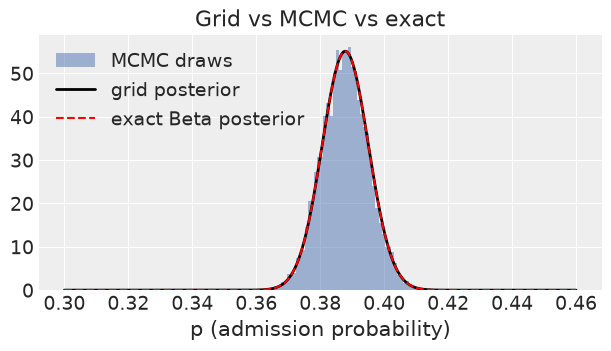

posterior mean — MCMC 0.3877 | grid 0.3879 | exact 0.3879


In [9]:
grid = np.linspace(0.30, 0.46, 2000)
logpost = st.beta.logpdf(grid, 2, 2) + st.binom.logpmf(tot_admit, tot_apps, grid)
post_grid = np.exp(logpost - logpost.max()); post_grid /= trapz(post_grid, grid)
conj = st.beta(2 + tot_admit, 2 + tot_apps - tot_admit)
draws = idata.posterior["p"].values.ravel()
plt.figure(figsize=(6,3.4))
plt.hist(draws, bins=60, density=True, alpha=.5, label="MCMC draws", color="#4c72b0")
plt.plot(grid, post_grid, "k-", lw=2, label="grid posterior")
plt.plot(grid, conj.pdf(grid), "r--", lw=1.5, label="exact Beta posterior")
plt.xlabel("p (admission probability)"); plt.legend(); plt.title("Grid vs MCMC vs exact"); plt.show()
print(f"posterior mean — MCMC {draws.mean():.4f} | grid {trapz(grid*post_grid,grid):.4f} | exact {conj.mean():.4f}")

## Stage 7 — Interpretation

In [10]:
m = draws.mean(); lo, hi = az.hdi(draws, hdi_prob=0.94)
print(f"Overall admission probability p = {m:.3f} (94% HDI {lo:.3f}-{hi:.3f})")
print(f"i.e. about {m*100:.0f} of every 100 applications were admitted, pooling all departments.")

Overall admission probability p = 0.388 (94% HDI 0.375-0.403)
i.e. about 39 of every 100 applications were admitted, pooling all departments.


## Stage 8 — Posterior predictive check
The pooled model has only one degree of freedom, so it reproduces the *total* admitted count by
construction. The informative PPC is at the **department level** — does one pooled p reproduce each
department's admitted count? Systematic misfit here is the paradox foreshadowed.

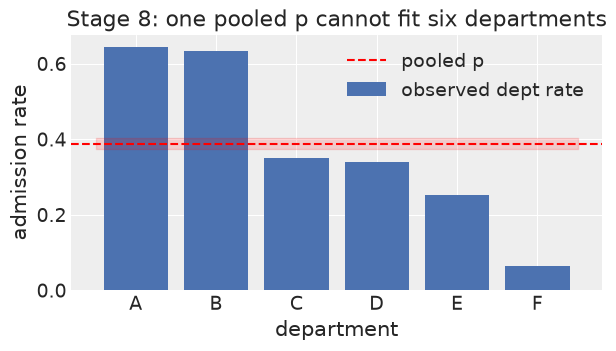

department rates range from 0.06 to 0.64 — far outside the pooled HDI.


In [11]:
dept_obs = df.groupby("dept").apply(lambda d: d.admit.sum()/d.applications.sum())
dept_n = df.groupby("dept").applications.sum()
ppc_p = draws
fig, ax = plt.subplots(figsize=(6,3.4))
ax.bar(range(len(dept_obs)), dept_obs.values, color="#4c72b0", label="observed dept rate")
ax.axhline(m, color="r", ls="--", label="pooled p")
ax.fill_between([-.5,len(dept_obs)-.5], lo, hi, color="r", alpha=.15)
ax.set_xticks(range(len(dept_obs))); ax.set_xticklabels(dept_obs.index)
ax.set_ylabel("admission rate"); ax.set_xlabel("department"); ax.legend()
ax.set_title("Stage 8: one pooled p cannot fit six departments"); plt.show()
print("department rates range from {:.2f} to {:.2f} — far outside the pooled HDI."
      .format(dept_obs.min(), dept_obs.max()))

## Stage 10 — Power-scaling prior sensitivity
Reweight the posterior by `prior^(alpha-1)` for the `Beta(2,2)` prior.

In [12]:
logprior = st.beta.logpdf(draws, 2, 2)
print("alpha   E[p]")
for a in [0.5, 1.0, 2.0]:
    w = np.exp((a-1)*logprior); w/=w.sum()
    print(f" {a:4.1f}   {np.sum(w*draws):.4f}")
print("With N>4500 applications the prior is irrelevant — p is fixed by the data.")

alpha   E[p]
  0.5   0.3876
  1.0   0.3877
  2.0   0.3877
With N>4500 applications the prior is irrelevant — p is fixed by the data.


## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** the Stage-8 plot shows a single pooled p **cannot** fit six
departments whose true rates span ~0.06–0.68. The expansion is **P07: admit ~ department + gender**
(a Binomial GLM), which dissolves the apparent gender gap — *Simpson's paradox*.

**Decision (Stage 12) — headline:** *the pooled Berkeley admission probability is ~0.39
(94% HDI 0.37–0.40), but this single number is misleading: admission rates vary enormously by
department, so a pooled rate must never be used to compare applicant groups.*

In [13]:
os.makedirs("report", exist_ok=True); idata.to_netcdf("report/P02_idata.nc"); print("saved report/P02_idata.nc")

saved report/P02_idata.nc


## Exercises
1. Re-fit with a flat `Beta(1,1)` prior. How much does the posterior move, and why so little?
2. Fit a **separate** p for each department. Plot the six posteriors — which departments admit most?
3. Compute the pooled admission rate for men and women separately, then for *each department*
   separately. Explain in one paragraph how the direction can reverse (Simpson's paradox).